## INDEX
Go to:<br>
[Acquiring initial data](#Acquiring_initial_data)<br>
[Downloading data](#Downloading_data)<br>
[Initial_analysis of the data](#Initial_analysis)<br>
[AIRPORTS_analysis](#AIRPORTS_analysis)<br>
[PSGR_vs_GDP](#PSGR_vs_GDP)<br>

# Mid term project
## My goal

I am interested in analysis of the field related to the aviation. My current job is related to this industry that is why it may be of special intrest to me. Selectoion of the dataset is more due to the curiosity then for any practical reason. One practical side effect of this work will be cleaning data which I will be albe to use outside of this project  I am interested is there any corelation to the size and GDP of country to its air passanger traffic. Also I am interested to see how covid affected those relations. In the process I am coursious if I will find some interesting data related to the passenger traffic and airports themselves. As an additional activity I will also analysie the physical properites of the runwaays on each airport. I expect to find some corelation in regard to civilian and military airports


## Acquiring initial data <a id='Acquiring_initial_data'></a>🔗

In [1]:
import requests
import pandas as pd
import numpy as np
import shutil
import os
import re
import inspect

## Importing modules for PLOTTING
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

##### Functions

In [2]:
def add_func_name():
    if True:
        return '\n\t\t("'+inspect.currentframe().f_back.f_code.co_name+'" function.)'

In [3]:
def print_red(text):
    red_text = f"\033[91m{text}\033[0m"
    print(red_text)

In [4]:
def max_col_OFF():
    pd.set_option('display.max_columns', None) # Removing restriction on the number of columns to display
    
def max_col_ON():
    pd.reset_option('display.max_columns')

In [5]:
def max_rows_OFF():
    pd.set_option('display.max_rows', None)

def max_rows_ON():
    pd.reset_option("display.max_rows")

In [6]:
def download_file(filename,request):
    if re.search(r"Backup_data", filename)==None and (request.status_code == 200):
        with open(filename, 'wb') as f:
            f.write(request.content)
#             print(f'"{filename}" downloaded.'+add_func_name())


In [7]:
def try_to_download_file(filename, response):
    try:
        response.raise_for_status()
        data_folder = "Data"
        file_path= "/".join([data_folder, filename])
    
#         print(f'Request was successful. \n"{filename}" can be downloaded.'+ add_func_name() )

    except requests.HTTPError as e:
        file_path = "/".join(["Backup_data", filename])
        print(print_red('An error occurred:' + str(e)))
        print(print_red(f'Use backup file: {file_path}'))

    return file_path

In [8]:
def save_and_return_dataframe_from_csv(filename,request):
    download_file(filename,request)
    df = pd.read_csv(filename)
    print(f'"{filename}" saved and read into the DataFrame.' + add_func_name())  
    return df

In [9]:
def extract_zip(zip_file):
    data_folder = "__".join(["Extracted", zip_file[:-4]])
    data_folder_path = "/".join(["Data",data_folder])
    
    zip_file_path = "/".join(["Data",zip_file])
    # Create folder for extracted files if do not exists
    os.makedirs(data_folder_path, exist_ok=True) 
    
    # Unzip ZIP file
    if os.path.exists(zip_file_path):
        shutil.unpack_archive(zip_file_path, data_folder_path,'zip')     
        print(f'"{zip_file}" extracted into \\{data_folder_path} ' + add_func_name())
    else:
        zip_file_path = "/".join(["Backup_data",zip_file])
        shutil.unpack_archive(zip_file_path, data_folder_path,'zip')     
        
        print(print_red(f"USING BACKUP FILE: {zip_file_path}"))
    
    
    return data_folder_path

In [41]:
def return_data_filename__worldbank(search_string, data_folder):
    files = shutil.os.listdir(data_folder)
    for f_name in files:
        if re.search(search_string, f_name) and not re.match(r"Metadata", f_name):
#             print("CSV data filename selected." + add_func_name())
            return f_name
    print("ERROR: No match." + add_func_name())
    return None

In [63]:
def get_worldbank_zip_into_csv_data_file_path(key_string, zip_filename):
    "key_string - is the string which is specific for the worldbank CSV data extracted for specific indicator"
    
    # Extracting zip file and passing extract folder
    extract_folder = extract_zip(zip_filename)
    
    # Finding csv data file and returning CSV data file name
    data_filename = return_data_filename__worldbank(key_string, extract_folder)
    file_path='/'.join([extract_folder,data_filename])
    
    # Returning relative path to the CSV data file
#     print(f'The CSV data path is: "{file_path}"' + add_func_name())
    return file_path

In [64]:
# Removing rows which do not represent countries
def remove_not_country_rows(df):
    return df[df['Country Code'].isin(countries['alpha-3'])]

## Downloading data <a id='Downloading_data'></a> 🔗

### Countries list

something to scrabe - country prefixes: https://en.wikipedia.org/wiki/ICAO_airport_code
Would be useful to add the continents for the runways data - many continents indicator missing. Using "country" list and the country name related to each "prefix" it may be possible to fix that data.

I have noticed that more data i have, more ideas to explore appear. 


In [65]:
countries_raw = pd.read_csv("Static_data/countries.csv")

# Keep only country name and 3-letter country code
countries = pd.DataFrame(countries_raw, columns=["name","alpha-3"]) 

### Airports data

In [66]:
# Creating data folder
os.makedirs("Data", exist_ok=True) 

In [67]:
## Getting airport database
URL1 = "https://ourairports.com/airports.csv"
response1 = requests.get(URL1)

In [68]:
filename = "airports_databas_raw.csv"
file_path = try_to_download_file(filename, response1)
airports= save_and_return_dataframe_from_csv(file_path, response1)
airports.shape

"Data/airports_databas_raw.csv" saved and read into the DataFrame.
		("save_and_return_dataframe_from_csv" function.)


(35161, 23)

### Runways data

In [69]:
# Getting runway data
URL2 = 'https://davidmegginson.github.io/ourairports-data/runways.csv'
response2 = requests.get(URL2)

filename ='runways_raw.csv'
file_path = try_to_download_file(filename, response2)
runways = save_and_return_dataframe_from_csv(file_path, response2)
runways.shape

"Data/runways_raw.csv" saved and read into the DataFrame.
		("save_and_return_dataframe_from_csv" function.)


(44916, 20)

### WORLD BANK - Passengers traffic per country (PSGR)

In [70]:
## Common parameters for all data downloaded from World Bank website
params={
    'downloadformat':'csv'
    }

In [71]:
URL3='https://api.worldbank.org/v2/en/indicator/IS.AIR.PSGR'
response3 = requests.get(URL3,params=params)
response3.url

'https://api.worldbank.org/v2/en/indicator/IS.AIR.PSGR?downloadformat=csv'

In [72]:
filename = "worldbank_PSGR.zip"
file_path = try_to_download_file(filename, response3)

download_file(file_path, response3)

file_path = get_worldbank_zip_into_csv_data_file_path("PSGR", filename)

worldbank_PSGR_raw = pd.read_csv(file_path, skiprows=3)
worldbank_PSGR_raw.shape

"worldbank_PSGR.zip" extracted into \Data/Extracted__worldbank_PSGR 
		("extract_zip" function.)


(266, 68)

### WORLD BANK - GDP per capita (GDP_PCAP)
https://data.worldbank.org/indicator/NY.GDP.PCAP.CD

In [73]:
URL4 = "https://api.worldbank.org/v2/en/indicator/NY.GDP.PCAP.KD"
response4 = requests.get(URL4, params=params)
response4.url

'https://api.worldbank.org/v2/en/indicator/NY.GDP.PCAP.KD?downloadformat=csv'

In [74]:
filename = "worldbank_GDP_PCAP.zip"
file_path = try_to_download_file(filename, response4)

download_file(file_path, response4)

file_path = get_worldbank_zip_into_csv_data_file_path("PCAP", filename)

worldbank__GDP_PCAP_raw = pd.read_csv(file_path, skiprows=3)
worldbank__GDP_PCAP_raw.shape

"worldbank_GDP_PCAP.zip" extracted into \Data/Extracted__worldbank_GDP_PCAP 
		("extract_zip" function.)


(266, 68)

### WORLD BANK - population

In [75]:
URL5 = "https://api.worldbank.org/v2/en/indicator/SP.POP.TOTL"
response5 = requests.get(URL5, params=params)
response5.url

'https://api.worldbank.org/v2/en/indicator/SP.POP.TOTL?downloadformat=csv'

In [76]:
filename = "worldbank_POP_TOTL.zip"
file_path = try_to_download_file(filename, response5)

download_file(file_path, response5)

file_path = get_worldbank_zip_into_csv_data_file_path("POP", filename)

worldbank__GDP_PCAP_raw = pd.read_csv(file_path, skiprows=3)
worldbank__GDP_PCAP_raw.shape

"worldbank_POP_TOTL.zip" extracted into \Data/Extracted__worldbank_POP_TOTL 
		("extract_zip" function.)


(266, 68)

### WORLD BANK - Countries surface areas
https://data.worldbank.org/indicator/AG.SRF.TOTL.K2

In [77]:
URL6 = "https://api.worldbank.org/v2/en/indicator/AG.SRF.TOTL.K2"
    
response6 = requests.get(URL6, params=params)
response6.url

'https://api.worldbank.org/v2/en/indicator/AG.SRF.TOTL.K2?downloadformat=csv'

In [78]:
filename = "worldbank_SRF_TOTL.zip"
file_path = try_to_download_file(filename, response6)

download_file(file_path, response6)

file_path = get_worldbank_zip_into_csv_data_file_path("SRF", filename)

worldbank__SURF_raw = pd.read_csv(file_path, skiprows=3)
worldbank__SURF_raw.shape

"worldbank_SRF_TOTL.zip" extracted into \Data/Extracted__worldbank_SRF_TOTL 
		("extract_zip" function.)


(266, 68)

### Worldbank Gross Domestic Product
https://data.worldbank.org/indicator/NY.GDP.MKTP.CD

In [79]:
URL7 = "https://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.CD"
    
response7 = requests.get(URL7, params=params)
response7.url

'https://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.CD?downloadformat=csv'

In [80]:
filename = "worldbank_GDP.zip"
file_path = try_to_download_file(filename, response6)

download_file(file_path, response7)

file_path = get_worldbank_zip_into_csv_data_file_path("GDP", filename)

worldbank__GDP_raw = pd.read_csv(file_path, skiprows=3)
worldbank__GDP_raw.shape

"worldbank_GDP.zip" extracted into \Data/Extracted__worldbank_GDP 
		("extract_zip" function.)


(266, 68)

### Our World in Data
https://ourworldindata.org/grapher/political-regime

In [81]:
legend = {
    0:"Closed autocracy",
    1:"Electoral autocracy",
    2:"Electoral democracy",
    3:"Liberal democracy",
}
regime = pd.read_csv("Static_data/political_regime.csv")   
regime.shape
# print(regime)

(30766, 4)

In [82]:
regime_wide = regime.pivot(index='Entity', columns='Year', values='regime_row_owid')
# print(regime_wide)

# Initial analysis of the data <a id='Initial_analysis'></a>🔗

Each downloaded World Bank csv file contains rows which actually are not countries, they may represent some regions or other aspects. The function used below removes those rows that contain non-country data

In [83]:
worldbank__GDP =  remove_not_country_rows(worldbank__GDP_raw)
worldbank__GDP_PCAP = remove_not_country_rows(worldbank__GDP_PCAP_raw)
worldbank__SURF = remove_not_country_rows(worldbank__SURF_raw)
worldbank__PSGR = remove_not_country_rows(worldbank_PSGR_raw)

At this point there are following dataframes uploaded into memory:
    airports - contains world airport data
    runways - contains more precise data related to the runways at each airport, such as length and width of the runway
    worldbank_PSGR - Passengers traffic per country data
    worldbank__GDP_PCAP - contains Gross Domestic product per capita for most of the countries
    

In [32]:
# Checking the Ai
# [item for item in airports.head(0)]

In [33]:
# Exploring how the data looks like
# airports.head(2)

In [34]:
# [item for item in runways.head(0)]

In [35]:
# Testing access to selected airport by its 4-letter ICAO code. In this case EPWA means Warsaw Chopin Airport , Poland
airport_ident = 'EPWA'
df = runways
# Boolean indexing to filter rows
filtered_rows = df[df['airport_ident'] == airport_ident]
# filtered_rows

In [36]:
## Converting from "wide format" to long format
df = worldbank_PSGR_raw
df_melted = df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], 
    value_vars=[str(i) for i in range(1960, 2023)],  # list the years here
    var_name='Year', 
    value_name='Value'
)

# filter out rows where 'Value' is NaN
df_melted = df_melted.dropna(subset=['Value'])
# df_melted

### Getting GDP per capita
By looking at the general chart of passenger numbers by country and my general knowledge regarding GDP of each country it is possible that the some kind of factor POPULATIONxGDP may infulence the passenger travel in some regions

Selection of the GDP per capita type:

"Comparisons of national wealth are frequently made on the basis of nominal GDP and savings (not just income), which do not reflect differences in the cost of living in different countries (see List of countries by GDP (nominal) per capita); hence, using a PPP basis is arguably more useful when comparing generalized differences in living standards between economies because PPP takes into account the relative cost of living and the inflation rates of the countries, rather than using only exchange rates, which may distort the real differences in income." 
Wikipedia , accesed on 06.07.2023 (https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(PPP)_per_capita)

### PSGR vs GDP analysis <a id="PSGR_vs_GDP"></a> 🔗

Here my goal is to compara passanger numbers traveling in a country to the coutries GDP. Next I will compare the to GDP per capita. One more type of comparission that includes gdp per capita nad the total population. As a reference I will compare data in 2018 which is the time before COVID pandemics.

In [106]:
worldbank__GDP['Country Name']
GDP_2018 = pd.Series(worldbank__GDP['2018'])
GDP_2018.index=worldbank__GDP['Country Name']

PSGR_2018 = pd.Series(worldbank__PSGR['2018'])
PSGR_2018.index=worldbank__PSGR['Country Name']

# Different approach - CONCATENATING series
GDP_PSGR_2018 = pd.concat([GDP_2018, PSGR_2018], axis=1, keys=['GDP_2018', 'PSGR_2018'])
GDP_PSGR_2018.dropna(inplace=True)

# Add allign factor column
GDP_PSGR_2018_sorted = GDP_PSGR_2018.sort_values('GDP_2018', ascending=False)


#### Align factor
# Calculate Canada's reference ratio (GDP/passengers)
df = GDP_PSGR_2018_sorted
reference_ratio = df.loc['Canada', 'GDP_2018'] / df.loc['Canada', 'PSGR_2018']

# Calculate ratio for each country and divide by reference ratio
df['align_factor'] = 1-((df['GDP_2018'] / df['PSGR_2018']) / reference_ratio)
GDP_PSGR_2018_sorted = df

# 
GDP_PSGR_2018_sorted_align_factor = GDP_PSGR_2018_sorted.sort_values(by="align_factor")

#### Limiting data 
# GDP_PSGR_2018_top = GDP_PSGR_2018_sorted.head(20)
GDP_PSGR_2018_top = GDP_PSGR_2018_sorted.iloc[:60]

def print_column_info(column):
    print("Min: {:.3f}".format(column.min()))
    print("Min ID: ", column.idxmin())
    print("Max:{:.3f}".format(column.max()))
    print("Max ID: ", column.idxmax())
    print("Mean:{:.3f}".format(column.mean()))

print_column_info(GDP_PSGR_2018_top.align_factor)

Min: -8.416
Min ID:  Cuba
Max:0.878
Max ID:  Ireland
Mean:-0.360


In [107]:
def plot_GDP_PSGR_2018_align_factor(df):
    df['align_factor'].plot(kind='bar', figsize=(14, 8))
    plt.title('GDP-to-Passenger Align Factor for Each Country')
    plt.ylabel('Align Factor')
    plt.xlabel('Country')
    plt.xticks(rotation=90)  # rotate x-axis labels for better visibility
    plt.show()

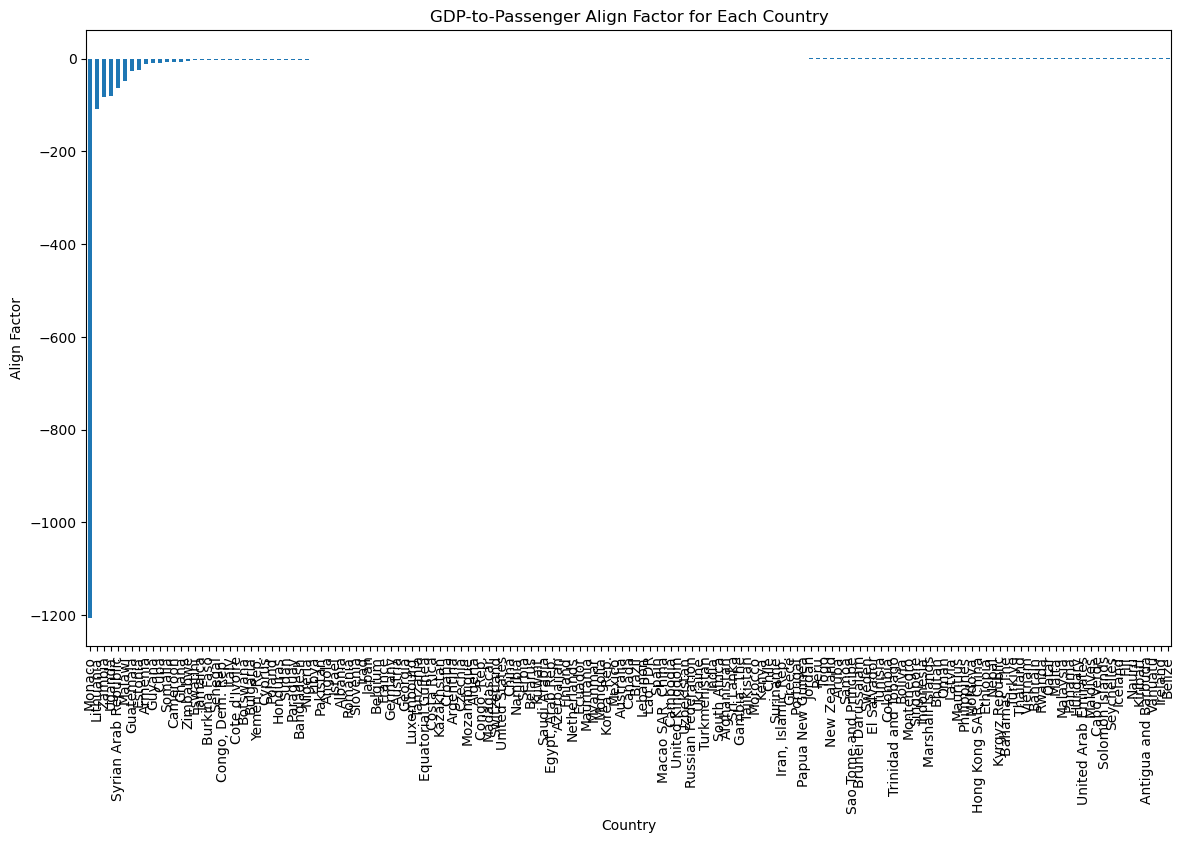

In [108]:
plot_GDP_PSGR_2018_align_factor(GDP_PSGR_2018_sorted_align_factor)
# plot_GDP_PSGR_2018_align_factor(GDP_PSGR_2018_top)

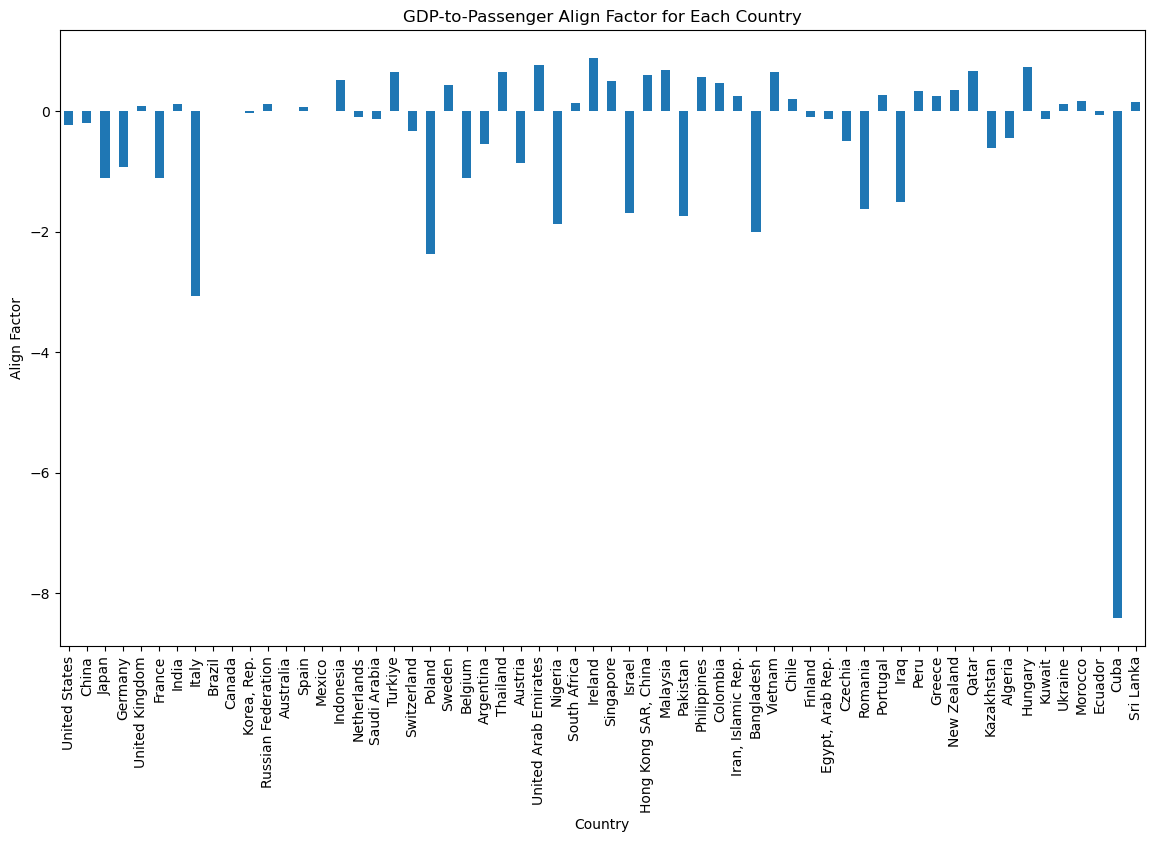

In [100]:
# Dropping extreme cases

# Monaco is second smalles country on the planet. I suspect that there may be not even single airport, maybe few helipads. That is why I remove it from the dataset
df = GDP_PSGR_2018_top
# df = plot_GDP_PSGR_2018_align_factor.drop(index =["Monaco"], axis=1)
plot_GDP_PSGR_2018_align_factor(df)

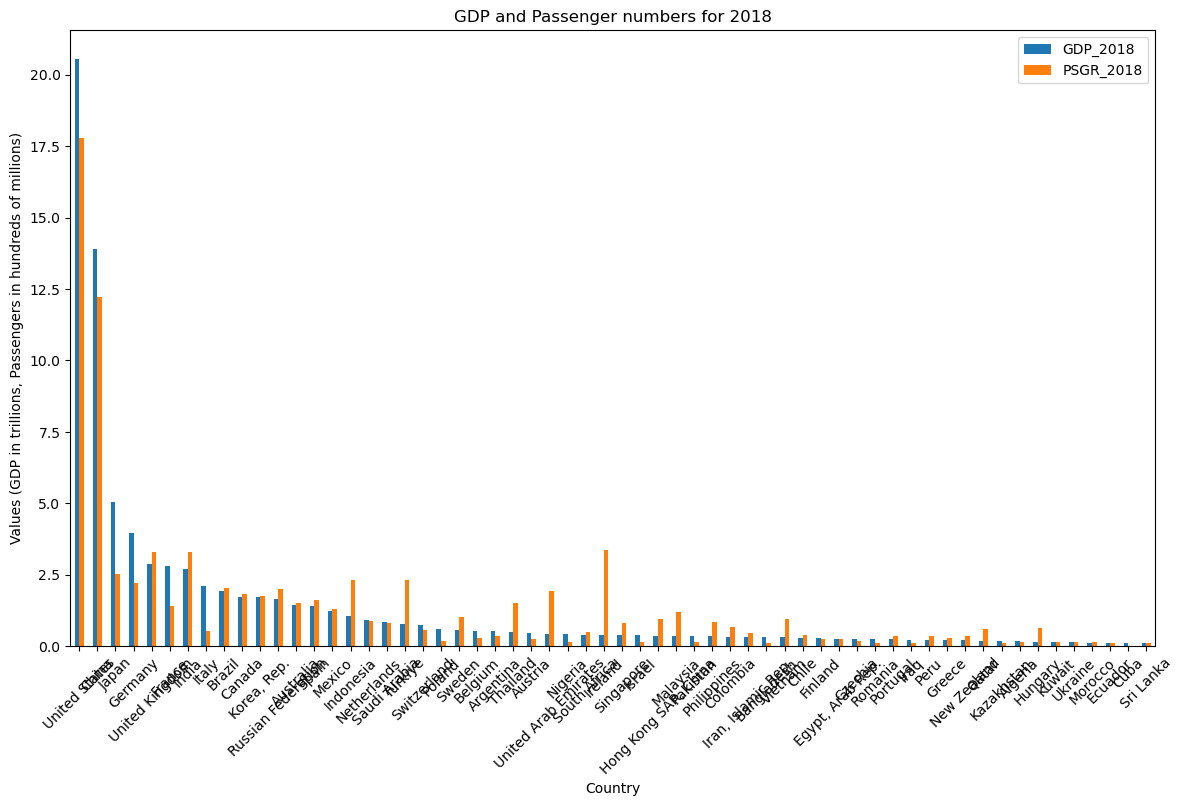

In [101]:
### Plotting
GDP_PSGR_2018_copy = GDP_PSGR_2018_top.copy().drop('align_factor', axis=1)  # Create a copy of the DataFrame

# Normalize the data
GDP_PSGR_2018_copy['GDP_2018'] = GDP_PSGR_2018_copy['GDP_2018'] / 1e12   # Convert to trillions
GDP_PSGR_2018_copy['PSGR_2018'] = GDP_PSGR_2018_copy['PSGR_2018'] / 0.5e8   # Convert to hundreds of millions

# GDP_PSGR_2018_top.plot(kind='bar', figsize=(14, 8))
GDP_PSGR_2018_copy.plot(kind='bar', figsize=(14, 8))
plt.title('GDP and Passenger numbers for 2018')
plt.ylabel('Values (GDP in trillions, Passengers in hundreds of millions)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

### AIRPORTS analysis <a id="AIRPORTS_analysis"></a> 🔗

In [ ]:
# airports.head(5)

In [ ]:
# New dataframe containing country name and all airport_idents in that country. Each ident can mean an airport/helipad or orther type of landing filed
country_airports = airports.groupby('country_name')['ident'].apply(list).reset_index()

In [ ]:
apts_by_index = country_airports.set_index('country_name')
#apts_by_index

In [ ]:
# First 10 airports
# apts_by_index.loc['Poland'].ident[:10]

In [ ]:
len(apts_by_index.loc['Poland'].ident)

#### Merging airports dataframe with runway dataframe

In [ ]:
# airports

In [ ]:
# runways

In [ ]:
### MERGING airports and runways dataframes
apt_and_rwys= pd.merge(airports, runways, left_on='ident', right_on='airport_ident')
apt_and_rwys.shape

In [ ]:
max_col_OFF()
# apt_and_rwys.head(6)

In [ ]:
selected_apt = apt_and_rwys[apt_and_rwys['ident'] == 'EPWA']

In [ ]:
# selected_apt 

In [ ]:
# [x for x in apt_and_rwys.head(0)]

In [ ]:
 #Check if 'ident' and 'airport_ident' columns are equal
print(len(apt_and_rwys['ident']), len(apt_and_rwys['airport_ident']))
are_equal = (apt_and_rwys['ident'] == apt_and_rwys['airport_ident']).all()
are_equal

In [ ]:
# Removing "airport_ident" column from the dataframe 
apt_and_rwys2 = apt_and_rwys.drop('airport_ident', axis=1)

In [ ]:
# Drop not required columns
apt_and_rwys3 = apt_and_rwys2.drop(['id_x','local_region','gps_code','home_link','keywords','score','id_y','last_updated','local_code','airport_ref'], axis=1)

In [ ]:
apt_and_rwys3.shape 

In [ ]:
max_col_OFF()
# apt_and_rwys3.head(3)

In [ ]:
# [x for x in apt_and_rwys3.head(0)]

In [ ]:
schedule_service_only_apts = apt_and_rwys3[apt_and_rwys3['scheduled_service'] == 1]
stripped = schedule_service_only_apts["ident"].squeeze()
only_sheduled_services_apts_ident = stripped.drop_duplicates()

only_sheduled_services_apts_ident.to_json("Modified_data/only_scheduled.json", orient="records")

In [ ]:
import json
with open('Modified_data/only_scheduled.json', "r") as file:
    data = json.load(file)

In [ ]:
idents_only = schedule_service_only_apts.drop_duplicates(subset='ident')
# CHecking unique values for some columns
unique_values = set(apt_and_rwys3['type'].unique())
print(unique_values)

In [ ]:
unique_values = set(apt_and_rwys3['continent'].unique())
unique_values

In [ ]:
# apt_and_rwys3.head(3)

In [ ]:
# CHecking how reliable is "continent column"
nan_count_in_continent = apt_and_rwys3['continent'].isna().sum()
nan_count_in_continent

There are thousends of airports, including major ones (e.g. KLAX that is Los Angeles) where the continent data is NaN. This means that I cannot rely very much to recognise the continent on which selected airport lies.

In [ ]:
nan_count = apt_and_rwys3['surface'].isna().sum()
nan_count

In [ ]:
# Since there is more tha fifteen thousand of NaNs in "continent" column, that makes it unreliable data, so I remove it from the dataset
apt_and_rwys4 = apt_and_rwys3.drop([ "municipality"], axis=1)
# apt_and_rwys4.head(5)

In [ ]:
df = apt_and_rwys4
df_180 = df[df['le_heading_degT'] == 180]

print(df_180[['ident','length_ft']])

In [ ]:
# apt_and_rwys4.head(3)
# df_180[df_180[""]]
# Reordering columns 
apt_and_rwys5 = pd.DataFrame(apt_and_rwys4,columns=['ident','iata_code','type','iso_country','country_name'])


In [ ]:
types = apt_and_rwys5.groupby(['country_name', 'type']).size()

types["Cuba"]

In [ ]:
cols_to_move = ['ident','iata_code','type','iso_country','country_name']
new_cols = cols_to_move + [col for col in apt_and_rwys4.columns if col not in cols_to_move]
apt_and_rwys5 = pd.DataFrame(apt_and_rwys4,columns=new_cols)

### Runways - GRAPHS

In [ ]:
df = apt_and_rwys4
df = df[df['continent'] == 'EU']
df = df[df['le_heading_degT'].between(0, 180)]

# now create a histogram with seaborn
plt.figure(figsize=(10,6))
sns.histplot(df['le_heading_degT'], bins=180, kde=False)

plt.title('Distribution of le_heading_degT - WORLD')
plt.xlabel('le_heading_degT (in degrees)')
plt.ylabel('Count')
plt.show()

In [ ]:
df = apt_and_rwys4
df = df[df['country_name'] == 'United States']
# df = df[df['le_heading_degT'].between(0, 180)]

## FILTERING AIRPORTS WHICH HAS le heading and no he heading
df = df[df['le_heading_degT'].between(0, 180) & df['he_heading_degT'].notna()]
# df = df[df['he_heading_degT'].notna()]
print(df.shape)


# now create a histogram with seaborn
plt.figure(figsize=(10,6))
sns.histplot(df['le_heading_degT'], bins=180, kde=False)

plt.title('Distribution of le_heading_deg - US')
plt.xlabel('le_heading_degT (in degrees)')
plt.ylabel('Count')
plt.show()

In [ ]:
df_180[df_180["type"]=="medium_airport"]

In [ ]:
df=df_180
df['length_rounded'] = df['length_ft'].apply(lambda x: int(np.round(x, -3)))

# count number of airports for each rounded length
df_count = df.groupby('length_rounded').size().reset_index(name='airport_count')

# create plot
plt.figure(figsize=(10, 6))
sns.barplot(x='length_rounded', y='airport_count', data=df_count, color='b')
plt.xlabel('Runway Length (ft, rounded to nearest 1000)')
plt.ylabel('Number of Airports')
plt.title('Number of Airports by Runway Length[ft] with the direction of 180deg')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df = apt_and_rwys4
df = df[df['country_name'] == 'China']
df = df[df['le_heading_degT'].between(0, 180)]

# now create a histogram with seaborn
plt.figure(figsize=(10,6))
sns.histplot(df['le_heading_degT'], bins=9, kde=False)

plt.title('Distribution of le_heading_degT')
plt.xlabel('le_heading_degT (in degrees)')
plt.ylabel('Count')
plt.show()

In [ ]:




## Printing countries names to see check what convention is used to call each 

# [print(x) for x in countries]



## Preparing PSGR_number to display on the year/PSGR_number initial plot

# Convert 'Year' to integer
df_melted['Year'] = df_melted['Year'].astype(int)

# List of countries to keep
countries_to_keep = ['Italy',"Germany", "Netherlands","United Kingdom" ]

# Filter dataframe
df_filtered = df_melted[df_melted['Country Name'].isin(countries_to_keep)]

### PLOTTING PSGR_NUM vs YEAR for SELECTED COUNTRIES
g=sns.relplot(kind="line",x="Year",y="Value", hue="Country Name",errorbar=None, data=df_filtered )

# Access the underlying matplotlib axes
ax = g.axes[0, 0]

# Format the y-axis tick labels with commas every thousand
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Display the plot
plt.show()